## Trial-relative time
Compute t_rel_ms per trial: time relative to trial onset.

In [6]:
import pandas as pd

def add_relative_time(df: pd.DataFrame, time_col: str = "time_ms") -> pd.DataFrame:
    """
    Add a column t_rel_ms = time within trial (ms),
    computed as time_ms - min(time_ms) per trial.

    Uses transform("min") instead of a Python lambda, which is much faster.
    """
    if time_col not in df.columns:
        raise ValueError(f"{time_col} column missing.")
    if "trial" not in df.columns:
        raise ValueError("trial column missing.")

    df = df.copy()

    # make sure time_ms is numeric
    df[time_col] = pd.to_numeric(df[time_col], errors="coerce")

    # relative time = time_ms - first time_ms in that trial (min)
    trial_min = df.groupby("trial")[time_col].transform("min")
    df["t_rel_ms"] = df[time_col] - trial_min

    return df

##  Baseline correction function

In [10]:
import pandas as pd
from pathlib import Path

# ---------- 1) Helpers ----------

def find_pupil_columns(df: pd.DataFrame):
    """
    Try to detect left/right pupil diameter columns in mm.
    Returns (left_col, right_col) or (None, None) if not found.
    """
    left_col = None
    right_col = None

    for c in df.columns:
        cl = c.lower()
        if "pupil" in cl and "left" in cl and "mm" in cl:
            left_col = c
        if "pupil" in cl and "right" in cl and "mm" in cl:
            right_col = c

    return left_col, right_col


def drop_rows_without_pupil(df: pd.DataFrame, left_col: str | None, right_col: str | None) -> pd.DataFrame:
    """
    Drop rows where both pupil columns (if present) are missing/empty.
    """
    cols = [c for c in [left_col, right_col] if c is not None and c in df.columns]
    if not cols:
        return df

    df = df.copy()
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    mask_has_any = df[cols].notna().any(axis=1)
    return df[mask_has_any].reset_index(drop=True)


def add_relative_time(df: pd.DataFrame, time_col: str = "time_ms") -> pd.DataFrame:
    """
    Fast relative time: t_rel_ms = time_ms - min(time_ms) per trial.
    """
    if time_col not in df.columns:
        raise ValueError(f"{time_col} column missing.")
    if "trial" not in df.columns:
        raise ValueError("trial column missing.")

    df = df.copy()
    df[time_col] = pd.to_numeric(df[time_col], errors="coerce")

    trial_min = df.groupby("trial")[time_col].transform("min")
    df["t_rel_ms"] = df[time_col] - trial_min
    return df


def baseline_correct_pupil(
    df: pd.DataFrame,
    baseline_window_ms: int = 500,
    time_rel_col: str = "t_rel_ms",
    pupil_cols=(),
) -> pd.DataFrame:
    """
    Baseline-correct given pupil columns per trial using the mean pupil size
    in the first `baseline_window_ms` ms. Adds <col>_bc columns.
    """
    if "trial" not in df.columns:
        raise ValueError("trial column missing.")
    if time_rel_col not in df.columns:
        raise ValueError(f"{time_rel_col} column missing. Run add_relative_time() first.")

    df = df.copy()

    # prepare new columns
    for col in pupil_cols:
        if col in df.columns:
            df[col + "_bc"] = pd.NA

    for trial_id, tdf in df.groupby("trial"):
        idx = tdf.index
        baseline_mask = tdf[time_rel_col] <= baseline_window_ms
        if not baseline_mask.any():
            continue

        for col in pupil_cols:
            if col not in df.columns:
                continue

            baseline_values = pd.to_numeric(
                tdf.loc[baseline_mask, col],
                errors="coerce"
            )

            if baseline_values.notna().sum() == 0:
                trial_values = pd.to_numeric(tdf[col], errors="coerce")
                if trial_values.notna().sum() == 0:
                    continue
                baseline = trial_values.mean()
            else:
                baseline = baseline_values.mean()

            trial_numeric = pd.to_numeric(df.loc[idx, col], errors="coerce")
            df.loc[idx, col + "_bc"] = trial_numeric - baseline

    return df


# ---------- 2) Apply to all participants ----------

trimmed_dir = Path("../data/by_participant_trimmed")
baseline_dir = Path("../data/by_participant_baseline")
baseline_dir.mkdir(parents=True, exist_ok=True)

summary = []

for csv_path in sorted(trimmed_dir.glob("participant_*.csv")):
    df = pd.read_csv(csv_path, low_memory=False)

    if "trial" not in df.columns or "time_ms" not in df.columns:
        print(f"Skipping {csv_path.name}: missing 'trial' or 'time_ms'")
        continue

    # detect pupil columns
    left_col, right_col = find_pupil_columns(df)
    if left_col is None and right_col is None:
        print(f"{csv_path.name}: no pupil columns found, skipping baseline.")
        continue

    pupil_cols = [c for c in [left_col, right_col] if c is not None]

    # drop rows with no pupil in either eye
    df = drop_rows_without_pupil(df, left_col, right_col)

    # add t_rel_ms
    if "t_rel_ms" not in df.columns:
        df = add_relative_time(df, time_col="time_ms")

    # baseline correct
    df_bc = baseline_correct_pupil(
        df,
        baseline_window_ms=500,
        time_rel_col="t_rel_ms",
        pupil_cols=pupil_cols,
    )

    # build unified names: if your original cols are e.g. "Pupil Diameter Left [mm]"
    # you will get "Pupil Diameter Left [mm]_bc" etc. That’s fine, or you can rename:
    rename_map = {}
    if left_col and left_col + "_bc" in df_bc.columns:
        rename_map[left_col + "_bc"] = "pupil_left_bc"
    if right_col and right_col + "_bc" in df_bc.columns:
        rename_map[right_col + "_bc"] = "pupil_right_bc"
    df_bc = df_bc.rename(columns=rename_map)

    # save
    out_path = baseline_dir / csv_path.name
    df_bc.to_csv(out_path, index=False)

    # quick stats
    stats = {}
    for col in ["pupil_left_bc", "pupil_right_bc"]:
        if col in df_bc.columns:
            s = pd.to_numeric(df_bc[col], errors="coerce")
            stats[col] = (s.min(), s.max())
        else:
            stats[col] = (None, None)

    pid = csv_path.stem.split("_")[-1]
    summary.append((pid, stats))

    print(
        f"{csv_path.name}: baseline corrected. "
        f"left_bc={stats['pupil_left_bc']}, right_bc={stats['pupil_right_bc']}"
    )

print("\n=== Baseline correction summary (min, max per pupil_bc column) ===")
for pid, stats in summary:
    print(f"Participant {pid}: {stats}")

participant_1.csv: baseline corrected. left_bc=(-1.805800000000001, 1.6839192307692308), right_bc=(-1.4809000000000019, 1.6277)
participant_10.csv: baseline corrected. left_bc=(-1.3511269230769232, 0.6210000000000004), right_bc=(-1.072907692307692, 1.0287000000000006)
participant_11.csv: baseline corrected. left_bc=(-1.6996000000000002, 1.6349846153846164), right_bc=(-3.2394, 4.6964999999999995)
participant_13.csv: baseline corrected. left_bc=(-1.2193769230769238, 6.120107692307692), right_bc=(-1.6048, 2.167580769230769)
participant_14.csv: baseline corrected. left_bc=(-2.943373076923077, 2.8688461538461536), right_bc=(-3.3503, 3.1602000000000006)
participant_15.csv: baseline corrected. left_bc=(-4.070983333333333, 6.004415384615386), right_bc=(-4.361533333333333, 3.1760000000000006)
participant_17.csv: baseline corrected. left_bc=(-3.660200000000001, 6.574700000000002), right_bc=(-4.591846153846154, 4.1273)
participant_18.csv: baseline corrected. left_bc=(-3.3331384615384616, 4.872507

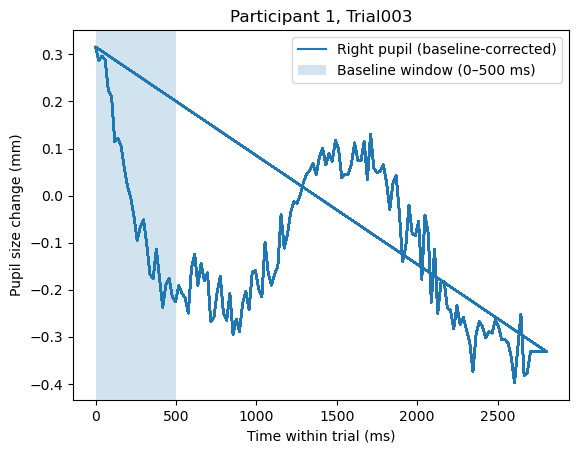

In [19]:
import matplotlib.pyplot as plt

example_path = baseline_dir / "participant_3.csv"  # change ID if you like
df_ex = pd.read_csv(example_path, low_memory=False)

trial_id = "Trial003"  # or another
sub = df_ex[df_ex["trial"] == trial_id]

plt.figure()
plt.plot(sub["t_rel_ms"], sub["pupil_right_bc"], label="Right pupil (baseline-corrected)", drawstyle='default')
plt.axvspan(0, 500, alpha=0.2, label="Baseline window (0–500 ms)")
plt.xlabel("Time within trial (ms)")
plt.ylabel("Pupil size change (mm)")
plt.title(f"Participant 1, {trial_id}")
plt.legend()
plt.show()